<a href="https://colab.research.google.com/github/codietg/Guardrail_Major_Project/blob/main/Notebooks/01_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pupose:**- Data loading & preprocessing

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# Set reproducible seed

import random, numpy as np, torch
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


Mounted at /content/drive


In [7]:
!pip install datasets



In [33]:
from datasets import load_dataset

In [34]:
# convert direct attack into indirect attacks
!pip install datasets pandas
from datasets import load_dataset
import pandas as pd
import random


In [35]:
safe_guard = load_dataset("xTRam1/safe-guard-prompt-injection")
alpaca = load_dataset("tatsu-lab/alpaca")
deepset = load_dataset("deepset/prompt-injections")


In [36]:
safe_guard["train"][0]


{'text': 'My question is: Alani earned $45 for 3 hours of baby-sitting. At the same rate, for how many hours would she need to baby-sit to earn $75? Your thoughts:',
 'label': 0}

In [37]:
safe_guard_train = safe_guard["train"].to_list()
alpaca_train = alpaca["train"].to_list()
deepset_train = deepset["train"].to_list()

In [38]:
def make_indirect(document, attack=None, rng=None):
    """Embed an attack string into a benign document at a random position."""
    if attack is None:
        return {"text": document, "label": 0}
    parts = document.split(". ")
    pos = rng.randint(0, len(parts))
    parts.insert(pos, attack)
    return {"text": ". ".join(parts), "label": 1}


In [39]:
rng = random.Random(42)

# Convert datasets to lists of dictionaries
safe_guard_train = safe_guard["train"].to_list()
alpaca_train = alpaca["train"].to_list()
deepset_train = deepset["train"].to_list()

# Split safe_guard into 80/20
split_point = int(0.8 * len(safe_guard_train))
train_safe = safe_guard_train[:split_point]
test_safe = safe_guard_train[split_point:]

# Prepare benign docs and attacks
train_docs = [ex["text"] for ex in alpaca_train[:len(train_safe)]]
train_attacks = [ex["text"] for ex in train_safe]

test_docs = [ex["text"] for ex in alpaca_train[:len(test_safe)]]
test_attacks = [ex["text"] for ex in test_safe]

ood_docs = [ex["text"] for ex in deepset_train]
ood_attacks = [ex["text"] for ex in deepset_train]



In [40]:
train_data = []
for doc, attack in zip(train_docs, train_attacks):
    train_data.append(make_indirect(doc, attack, rng))   # positive
    train_data.append(make_indirect(doc, None, rng))     # negative

test_in_data = []
for doc, attack in zip(test_docs, test_attacks):
    if rng.random() < 0.15:  # 15% chance to insert attack
        test_in_data.append(make_indirect(doc, attack, rng))
    else:
        test_in_data.append(make_indirect(doc, None, rng))

test_ood_data = []
for doc, attack in zip(ood_docs, ood_attacks):
    if rng.random() < 0.15:  # 15% chance to insert attack
        test_ood_data.append(make_indirect(doc, attack, rng))
    else:
        test_ood_data.append(make_indirect(doc, None, rng))

In [41]:

# Save them
pd.DataFrame(train_data).to_csv('/content/drive/MyDrive/data/train.csv', index=False)
pd.DataFrame(test_in_data).to_csv('/content/drive/MyDrive/data/test_in.csv', index=False)
pd.DataFrame(test_ood_data).to_csv('/content/drive/MyDrive/data/test_ood.csv', index=False)


In [42]:
for name in ["train", "test_in", "test_ood"]:
    df = pd.read_csv(f"/content/drive/MyDrive/data/{name}.csv")
    print(name, df['label'].value_counts())


train label
1    6588
0    6588
Name: count, dtype: int64
test_in label
0    1384
1     264
Name: count, dtype: int64
test_ood label
0    468
1     78
Name: count, dtype: int64


# **observation**
Train: roughly equal 0s and 1s (balanced).\
Test in /Test ood: mostly 0s (benign) with ~15 % 1s (attacks).

**Visualisation of the dataset**

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
train_df = pd.DataFrame(train_data)
test_in_df = pd.DataFrame(test_in_data)
test_ood_df = pd.DataFrame(test_ood_data)

/tmp/ipykernel_2145/4122609595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='coolwarm')
/tmp/ipykernel_2145/4122609595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='coolwarm')
/tmp/ipykernel_2145/4122609595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='coolwarm')


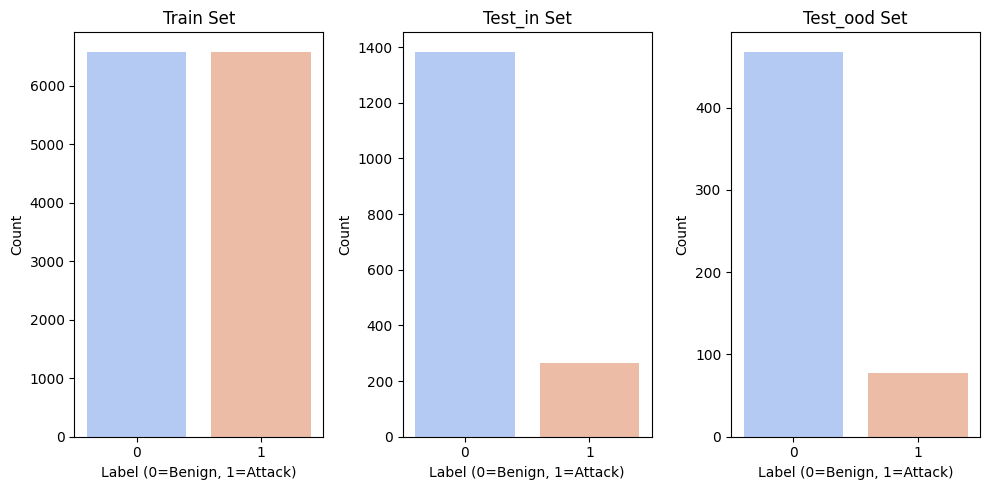

In [45]:
datasets = {'Train': train_df, 'Test_in': test_in_df, 'Test_ood': test_ood_df}
plt.figure(figsize=(10,5))

for i, (name, df) in enumerate(datasets.items(), 1):
    plt.subplot(1,3,i)
    sns.countplot(x='label', data=df, palette='coolwarm')
    plt.title(f'{name} Set')
    plt.xlabel('Label (0=Benign, 1=Attack)')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


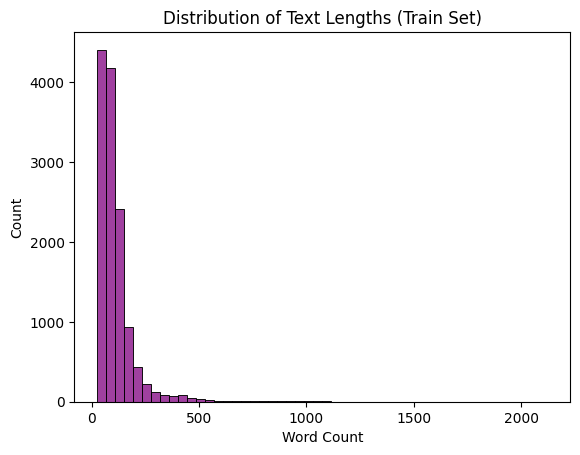

In [46]:
train_df['length'] = train_df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(train_df['length'], bins=50, color='purple')
plt.title('Distribution of Text Lengths (Train Set)')
plt.xlabel('Word Count')
plt.show()
